# Training-window ablation — verify, then interpret

**Verify first.** `train_window` ties the Ridge fit window *and* the robust-scaler window;
each window is scored on a common OOS so the comparison is the window effect, not a
different test period. Below, **HAR's whole window grid is re-run live** (the real
`_backtest_and_save` common-OOS loop) and asserted to reproduce the cluster grid — that
anchors the machinery locally. The full per-bucket grid (hours to re-run locally) is
**cluster-computed by that same verified machinery**; provenance is stated where used.
**Interpret second** — curves drawn from the verified grid, never an opaque number.

In [1]:
import ast, html, inspect, os, sys, textwrap, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown

def find_repo(s):
    for q in [Path(s).resolve(), *Path(s).resolve().parents]:
        if (q / "src" / "models" / "ridge.py").exists() and (q / "data").exists(): return q
    raise FileNotFoundError("repo root")
REPO = find_repo(Path.cwd()); os.chdir(REPO); sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO)+'/experiments')
import tqdm as _t; from functools import partialmethod
_t.tqdm.__init__ = partialmethod(_t.tqdm.__init__, disable=True)

from src.backtest.executor import load_and_transform, _build_har_and_calendar, _backtest_and_save
from src.features.extractors.har import resolve_har_lags
from src.models.ridge import fit_predict_ridge
from src.evaluation.metrics import calculate_metrics

def show_one(f, open_=False):
    path = f.__module__.replace("src.", "src/").replace(".", "/") + ".py"
    try: sig = "def " + f.__name__ + str(inspect.signature(f))
    except (ValueError, TypeError): sig = f.__qualname__
    body = "```python\n" + textwrap.dedent(inspect.getsource(f)).rstrip() + "\n```"
    return Markdown(f"<details{' open' if open_ else ''}>\n<summary><code>{html.escape(path+'  ·  '+sig)}"
                    f"</code></summary>\n\n{body}\n\n</details>")
print("setup ok")

setup ok


---
## 1 · Verify — HAR's window grid, re-run live, reproduces the cluster

The window-ablation machinery is `_backtest_and_save` with the common-OOS start passed in
(`start=FIXED`); the per-bar internals are the same pipeline proven in
`ridge_pipeline_throughline.ipynb`. Body folded:

In [2]:
show_one(_backtest_and_save)

<details>
<summary><code>src/backtest/executor.py  ·  def _backtest_and_save(df: &#x27;pd.DataFrame&#x27;, feature_names: &#x27;list[str]&#x27;, fit_predict: &#x27;FitPredict&#x27;, hyperparams: &#x27;dict&#x27;, train_win_periods: &#x27;int&#x27;, horizon: &#x27;int&#x27;, start: &#x27;int&#x27;, end: &#x27;int&#x27;, halo: &#x27;int&#x27;, output_file: &#x27;str&#x27;, prescale: &#x27;bool&#x27; = False, diurnal_mode: &#x27;str&#x27; = &#x27;divide&#x27;) -&gt; &#x27;None&#x27;</code></summary>

```python
def _backtest_and_save(
    df: pd.DataFrame,
    feature_names: list[str],
    fit_predict: FitPredict,
    hyperparams: dict,
    train_win_periods: int,
    horizon: int,
    start: int,
    end: int,
    halo: int,
    output_file: str,
    prescale: bool = False,
    diurnal_mode: str = "divide",
) -> None:
    """Run a prepared DataFrame through the walk-forward backtest and save.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain ``adj_RV``, ``baseline``, ``t``, plus all
        ``feature_names`` columns. The HAR-burn-in (``max_lag``) rows
        are dropped here before any extraction.
    feature_names : list[str]
        Column names in ``df`` that form the feature matrix.
    fit_predict : FitPredict
        Callable ``(X_chunk, y_chunk, train_win_periods, hyperparams)
        -> preds`` of shape ``(len(X_chunk) - train_win_periods,)``.
    hyperparams : dict
        Method-specific hyperparameters (typically a merge of method
        defaults and tuned overrides from ``--params-file``).
    train_win_periods : int
        Training window in 30-min periods.
    horizon : int
        Forecast horizon in 30-min periods.
    start, end, halo : int
        The framework slice for this task, in *post horizon-shift* index
        space (the fields of ``hpc_agent.template.SliceSpec``). ``[start,
        end)`` is the emit range; ``halo`` is the count of warm-up rows
        replayed before it, so the chunk processed is
        ``X[start - halo : end]`` and its first ``halo`` rows train the
        model without emitting predictions (``halo`` is sized to the
        training window). ``end < 0`` means "to the end"; a whole-series
        run is ``start=0, end=-1, halo=0``.
    output_file : str
        Output CSV path. ``<basename>_reduce.json`` is written
        alongside.
    prescale : bool, default False
        If True, rolling-robust-scale the whole feature matrix
        (``rolling_robust_scale``) *before* the chunk slice — the linear /
        distance-based methods (Ridge, kNN, spectral_knn) need feature
        standardization, and doing it whole-series keeps the scaler's
        look-back out of the backtest so a ``halo == train_win`` chunk is
        fungible. Tree methods leave this False (they neither scale nor
        prescale). The matching ``fit_predict`` receives an already-scaled
        ``X_chunk`` and passes it through to its
        :class:`~src.backtest.multi_stage.MultiStageBacktest`.
    """
    max_lag = resolve_har_lags()[-1]
    df = df.iloc[max_lag:].reset_index(drop=True)

    X = df[feature_names].values.astype(np.float64)
    y = df["adj_RV"].values.astype(np.float64)
    dates = df["t"]
    baselines = df["baseline"].values.astype(np.float64)

    X, y, dates, baselines = apply_horizon_shift(X, y, dates, baselines, horizon)

    # Rolling robust scaling is a bounded-window transform; doing it here,
    # whole-series, keeps its look-back out of the per-chunk backtest (see
    # rolling_robust_scale). The slice below then cuts the pre-scaled array.
    if prescale:
        ref_iqr, fixed_cols = _build_scale_guards(
            X, df, feature_names, zero_inflated_active=(diurnal_mode != "rank")
        )
        X = rolling_robust_scale(
            X, train_win_periods, ref_iqr=ref_iqr, fixed_cols=fixed_cols
        )

    load_start = max(0, start - halo)
    actual_end = len(X) if end < 0 else end
    X_chunk = X[load_start:actual_end]
    y_chunk = y[load_start:actual_end]
    dates_chunk = dates.iloc[load_start:actual_end].reset_index(drop=True)
    baselines_chunk = baselines[load_start:actual_end]

    if train_win_periods >= len(X_chunk):
        raise ValueError(
            f"train_window ({train_win_periods} periods) >= chunk size ({len(X_chunk)})"
        )

    preds = fit_predict(X_chunk, y_chunk, train_win_periods, hyperparams)

    oos_start = train_win_periods
    y_oos = y_chunk[oos_start:]
    dates_oos = dates_chunk.iloc[oos_start:].values
    baselines_oos = baselines_chunk[oos_start:]

    pred_raw, true_raw = apply_duan_smearing(preds, y_oos, baselines_oos)

    results = pd.DataFrame(
        {
            "date": dates_oos,
            "horizon": horizon,
            "true_adj": y_oos,
            "pred_adj": preds,
            "true_raw": true_raw,
            "pred_raw": pred_raw,
        }
    )

    os.makedirs(os.path.dirname(output_file) or ".", exist_ok=True)
    results.to_csv(output_file, index=False)
    save_chunk_reduce(results, output_file)
    print(f"Saved {len(results)} rows -> {output_file}")
```

</details>

**Source — the rest of the window-ablation pipeline.** `_backtest_and_save` (folded above) is the common-OOS loop; the `src/` functions it drives are mirrored below, static, each framed to its job. The full per-bucket cluster grid in `results/cluster_train_window_ablation.csv` (Hoffman2) was produced by this same code path — these sources are what stand behind the cluster numbers, shown so the grid stays auditable even though it is not re-run locally. 

`load_and_transform` builds each window's design matrix — raw parquet -> diurnally-adjusted, winsorized sqrt-RV target, plus the impute-indicate and zero-inflation/hurdle exog encodings:

<details>
<summary><code>src/backtest/executor.py :: load_and_transform</code></summary>

```python
def load_and_transform(
    data_path: str,
    exog_cols: list[str],
    *,
    target_use_diurnal: bool,
    target_winsor_window: int | None,
    dropna_with_exog: bool,
    overnight_fill: bool = True,
    impute_indicate: bool = False,
    diurnal_mode: str = "divide",
    use_semantic: bool = True,
) -> tuple[pd.DataFrame, list[str]]:
    """Load raw data, apply RV + exog robust transforms, return (df, adj_exog).

    ``diurnal_mode`` (``"divide"`` | ``"rank"``) selects how the per-slot diurnal
    adjustment is done for the EXOG features: the default divide, or the
    division-free per-slot rank-Gauss (:func:`diurnal_rank`). The target's diurnal
    is always divide (its raw reconstruction needs the multiplicative baseline).

    Parameters
    ----------
    data_path : str
        Forwarded to ``load_raw_data``.
    exog_cols : list[str]
        Raw exog column names (pre-transform). May be empty.
    target_use_diurnal : bool
        If True, apply diurnal adjustment to the RV target transform.
        Tree methods: True. Ridge: False.
    target_winsor_window : int | None
        Winsorization window for the RV target. Tree methods: 240.
        Ridge: None (no winsorization beyond ``robust_transform``
        defaults).
    dropna_with_exog : bool
        Exog columns are forward-filled before this branch, so the only
        rows that can still have NaN exog are at the leading edge of the
        dataset (before any valid value). If True, drop those rows.
        Ridge: True (sklearn Ridge requires no NaN). Tree methods: False
        (trees handle NaN natively).
    overnight_fill : bool
        If True (default, legacy behaviour), fill matching exog columns with
        1.0 in their overnight window before ffill. This substring-matches
        moment columns (``sumret3_*`` etc.) and fills them with 1.0, which is
        a latent bug for non-ratio columns — set False for clean ffill-only.
    """
    df = load_raw_data(data_path, allow_missing=True)
    if exog_cols:
        if overnight_fill:
            apply_overnight_fills(df, exog_cols)
        df[exog_cols] = df[exog_cols].ffill()
        if dropna_with_exog and not impute_indicate:
            df = df.dropna(subset=["RV"] + exog_cols).reset_index(drop=True)
        else:
            # impute_indicate keeps exog-missing rows (filled + flagged below).
            df = df.dropna(subset=["RV"]).reset_index(drop=True)

    transform_kwargs: dict = {"is_target": True}
    if target_use_diurnal:
        transform_kwargs["use_diurnal"] = True
    if target_winsor_window is not None:
        transform_kwargs["winsor_window"] = target_winsor_window
    adj_rv, baseline = robust_transform(df, "RV", **transform_kwargs)
    df["adj_RV"] = adj_rv
    df["baseline"] = baseline

    adj_exog_cols: list[str] = []
    for col in exog_cols:
        adj_col = f"adj_{col}"
        adj_series, _ = robust_transform(df, col, use_transform=use_semantic, use_diurnal=True, diurnal_mode=diurnal_mode)
        df[adj_col] = adj_series
        adj_exog_cols.append(adj_col)

    if impute_indicate and exog_cols:
        # Impute-and-indicate: instead of dropping rows where an exog is
        # structurally absent (which shrinks the sample and breaks cross-arm
        # QLIKE comparability), fill its adjusted feature with 0 (neutral) and
        # add a ``<col>_avail`` availability indicator. Every row is then
        # scored and the model can down-weight the feature where it's absent.
        for col in exog_cols:
            # Neutral fill must be in-distribution in the *transformed* space:
            # the feature's own median. 0 is wrong (e.g. adj_vix = log(vix), so
            # fillna(0) imputes vix = exp(0) = 1, a wild value that blew the
            # Ridge forecast up to QLIKE ~2.4). Median ≈ neutral, prescales to 0.
            adj = df[f"adj_{col}"]
            df[f"adj_{col}"] = adj.fillna(adj.median())
            avail = f"{col}_avail"
            df[avail] = df[col].notna().astype("float64")
            adj_exog_cols.append(avail)

    # Hurdle (two-part) encoding for zero-inflated exog. A sparse signed flow
    # like voldemand is a mixture — a point mass at 0 ("no demand") plus a
    # continuous demand distribution — so a single robust scale is degenerate
    # (the zero mass collapses the IQR). Add an occurrence indicator so the
    # model separates the extensive margin (is there demand at all) from the
    # intensive margin (how big); the magnitude's scale is taken over the
    # active (non-zero) values in ``_build_scale_guards``.
    for col in exog_cols:
        vals = df[col].to_numpy(dtype=np.float64)
        finite = vals[~np.isnan(vals)]
        if finite.size and float(np.mean(finite == 0.0)) >= ZERO_INFLATED_FRAC:
            active = f"{col}_active"
            df[active] = (np.nan_to_num(vals) != 0.0).astype("float64")
            adj_exog_cols.append(active)

    return df, adj_exog_cols
```

</details>

`_build_har_and_calendar` adds the HAR features, the calendar dummies, and the distilled HAR×session-edge interactions that every window is fit on:

<details>
<summary><code>src/backtest/executor.py :: _build_har_and_calendar</code></summary>

```python
def _build_har_and_calendar(df, exog_cols, add_calendar):
    df, har_names = generate_har_features(df, target_col="adj_RV", exog_cols=exog_cols)
    if add_calendar:
        feature_names = har_names + add_calendar_features(df)
        # HAR x open/close session-edge interactions (the distilled intraday vol-persistence
        # sign-flip: high recent RV -> LOWER future RV at the 09:30 open and 16:00 close/AH).
        # Materialized upstream so every model + the cached matrix inherit them; causal (the
        # is_open/is_close gates are pure functions of the timestamp). Mirrors the no-rebuild
        # resid_amortized._regime_interactions, identical naming (har_ma_{w}_x_{open,close}).
        for h in [c for c in har_names if c.startswith("har_ma_")]:  # the 6 target-HAR cols
            for gate, suffix in (("is_open", "open"), ("is_close", "close")):
                name = f"{h}_x_{suffix}"  # matches resid_amortized: har_ma_{w}_x_{open,close}
                df[name] = df[h] * df[gate]
                feature_names.append(name)
    else:
        feature_names = har_names
    return df, feature_names
```

</details>

`resolve_har_lags` fixes the powers-of-5 HAR lag grid `[1, 5, 25, 125, 625, 3125]` the feature build above expands:

<details>
<summary><code>src/features/extractors/har.py :: resolve_har_lags</code></summary>

```python
def resolve_har_lags(max_lag: int = 3125) -> list[int]:
    """Powers-of-5 lag sequence: [1, 5, 25, 125, 625, 3125]."""
    seq, v = [], 1
    while v <= max_lag:
        seq.append(v)
        v *= 5
    return seq
```

</details>

`fit_predict_ridge` is the per-bar fit `_backtest_and_save` calls each step — the rank-1 incremental solver (identical to a per-window sklearn refit) that makes the full window grid feasible:

<details>
<summary><code>src/models/ridge.py :: fit_predict_ridge</code></summary>

```python
def fit_predict_ridge(
    X_chunk: np.ndarray,
    y_chunk: np.ndarray,
    train_win_periods: int,
    hyperparams: dict,
) -> np.ndarray:
    """Walk-forward Ridge regression via :class:`MultiStageBacktest`.

    Plain single-stage model: ``IdentityResidualizer`` + no feature transform
    + ``Ridge`` regressor. The feature matrix is rolling-robust-scaled
    whole-series upstream (``prescale=True`` in :func:`run_executor`).
    Refit cadence comes from ``hyperparams['_refit_frequency']``.
    Internal control keys (``_*``) are stripped before forwarding to ``Ridge``.
    """
    refit_frequency = int(hyperparams.get("_refit_frequency", 1))
    incremental = bool(hyperparams.get("_incremental", True))
    model_kwargs = {k: v for k, v in hyperparams.items() if not k.startswith("_")}

    if incremental:
        # Rank-1 sliding-window solver: predictions identical to a per-window
        # Ridge refit, at O(p²)/bar instead of O(W·p²)/bar. MultiStageBacktest
        # detects the rolling protocol (init_window + roll) and takes its
        # incremental fast path. Falls back to sklearn Ridge for any model_kwarg
        # the rolling solver doesn't model (set incremental=False then).
        alpha = float(model_kwargs.get("alpha", 1.0))
        fit_intercept = bool(model_kwargs.get("fit_intercept", True))

        def make_regressor() -> Any:
            return RollingLeastSquares(alpha=alpha, fit_intercept=fit_intercept)
    else:

        def make_regressor() -> Any:
            return Ridge(**model_kwargs)

    backtest = MultiStageBacktest(
        residualizer=IdentityResidualizer(),
        regressor_factory=make_regressor,
        refit_frequency=refit_frequency,
    )
    return backtest.run(X_chunk, y_chunk, train_win_periods, desc="ridge")
```

</details>

`calculate_metrics` turns each window's OOS `results.csv` into the raw-scale QLIKE plotted below, via Duan smearing:

<details>
<summary><code>src/evaluation/metrics.py :: calculate_metrics</code></summary>

```python
def calculate_metrics(df: pd.DataFrame) -> dict:
    """Compute evaluation metrics from a results DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: true_adj, pred_adj, true_raw, pred_raw.

    Returns
    -------
    dict
        Keys: mse, mae, w_mse, w_mae, qlike, w_qlike, n_samples.
    """
    true_adj = df["true_adj"].values
    pred_adj = df["pred_adj"].values
    true_raw = df["true_raw"].values
    pred_raw = df["pred_raw"].values

    # --- Adjusted-scale errors ---
    errors = true_adj - pred_adj
    mse = float(np.mean(errors**2))
    mae = float(np.mean(np.abs(errors)))

    # Winsorized variants
    w_errors = winsorize_array(errors)
    w_mse = float(np.mean(w_errors**2))
    w_mae = float(np.mean(np.abs(w_errors)))

    # --- QLIKE (raw scale) ---
    mask = (true_raw > 0) & (pred_raw > 0)
    if mask.sum() > 0:
        ratio = true_raw[mask] / pred_raw[mask]
        qlike_vals = ratio - np.log(ratio) - 1.0
        qlike = float(np.mean(qlike_vals))
        w_qlike = float(np.mean(winsorize_array(qlike_vals)))
    else:
        qlike = np.nan
        w_qlike = np.nan

    return {
        "mse": mse,
        "mae": mae,
        "w_mse": w_mse,
        "w_mae": w_mae,
        "qlike": qlike,
        "w_qlike": w_qlike,
        "n_samples": len(df),
    }
```

</details>

Re-run HAR over the cluster's window grid and compare (this is a real walk-forward per window — a few minutes):

In [3]:
dfh, adjh = load_and_transform("data", [], target_use_diurnal=True, target_winsor_window=240,
                               dropna_with_exog=True, overnight_fill=False, impute_indicate=False)
dfh, featsh = _build_har_and_calendar(dfh, adjh, True)
WINDOWS = [60, 125, 250, 500, 1000, 1500, 2000]; FIXED = max(WINDOWS) * 48
hp = {"alpha": 1.0, "_refit_frequency": 1, "_incremental": True}
out = "results/repro/winabl/HAR.csv"; os.makedirs(os.path.dirname(out), exist_ok=True)
rows = []
for wd in WINDOWS:
    tw = wd * 48
    _backtest_and_save(dfh, featsh, fit_predict_ridge, hp, tw, 1, FIXED, -1, tw, out, True)
    rows.append({"window_days": wd, "qlike_local": round(float(calculate_metrics(pd.read_csv(out))["qlike"]), 5)})
har_live = pd.DataFrame(rows)

cl = pd.read_csv("results/cluster_train_window_ablation.csv")
clh = cl[cl.bucket == "HAR"][["window_days", "qlike"]].rename(columns={"qlike": "qlike_cluster"})
chk = har_live.merge(clh, on="window_days"); chk["d"] = (chk.qlike_local - chk.qlike_cluster).round(6)
display(chk)
assert chk.d.abs().max() < 1e-4, chk
assert int(har_live.loc[har_live.qlike_local.idxmin(), "window_days"]) == 250
print(f"PASS - HAR window grid reproduces cluster (max|d|={chk.d.abs().max():.1e}); argmin=250, live.")

Saved 146934 rows -> results/repro/winabl/HAR.csv


Saved 146934 rows -> results/repro/winabl/HAR.csv


Saved 146934 rows -> results/repro/winabl/HAR.csv


Saved 146934 rows -> results/repro/winabl/HAR.csv


Saved 146934 rows -> results/repro/winabl/HAR.csv


Saved 146934 rows -> results/repro/winabl/HAR.csv


Saved 146934 rows -> results/repro/winabl/HAR.csv


,window_days,qlike_local,qlike_cluster,d
0,60,0.14242,0.14242,0.0
1,125,0.13957,0.13957,0.0
2,250,0.13804,0.13804,0.0
3,500,0.13947,0.13947,0.0
4,1000,0.13927,0.13927,0.0
5,1500,0.13964,0.13964,0.0
6,2000,0.14001,0.14001,0.0


PASS - HAR window grid reproduces cluster (max|d|=0.0e+00); argmin=250, live.


✓ The window machinery is verified locally. The full per-bucket grid below is the
cluster output (`results/cluster_train_window_ablation.csv`, Hoffman2) produced by this
same code path — every absolute QLIKE only comparable *within* its OOS group (OOS-start =
`max(window)·48`), so cross-bucket claims use Δ-vs-own-500.

---
## 2 · Interpret

The cluster grid, now that the machinery is verified.

In [4]:
win = pd.read_csv("results/cluster_train_window_ablation.csv")
LABEL = {"HAR":"HAR","moments":"moments","liquidity":"liquidity","implied_vol":"implied_vol",
         "market_vw":"market_vw","market_ew":"market_ew","vol_demand":"vol_demand",
         "sentiment":"sentiment","all_buckets":"all_buckets"}
COLORS = {b:c for b,c in zip(LABEL, plt.cm.tab10(np.linspace(0,1,10)))}
def has(b,w): g=win[win.bucket==b]; return w in g.window_days.values
single = [b for b in LABEL if b not in ("all_buckets",) and has(b,250) and has(b,500)]

**Single buckets — the optimum is ≈250 days, universally** (Δ vs each bucket's own 500-day):

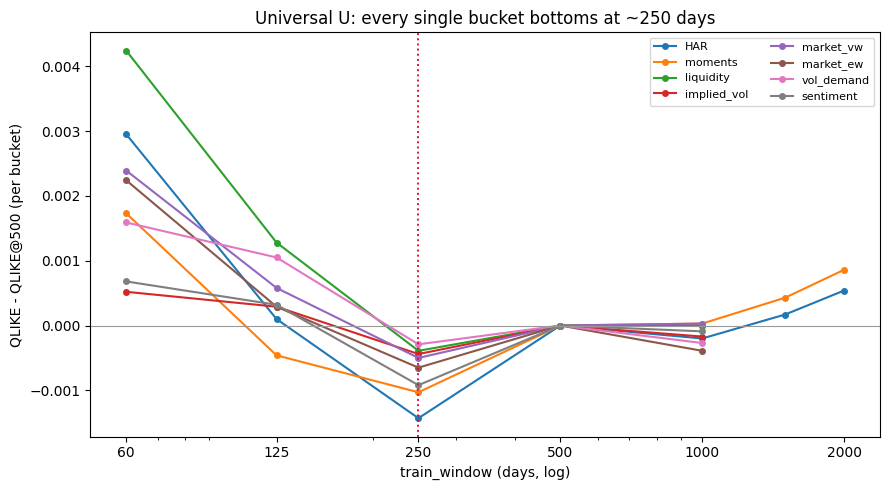

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for b in single:
    g = win[win.bucket==b].sort_values("window_days")
    q500 = g.loc[g.window_days==500,"qlike"].iloc[0]
    ax.plot(g.window_days, g.qlike-q500, "o-", ms=4, color=COLORS[b], label=LABEL[b])
ax.axvline(250, ls=":", c="crimson", lw=1.4); ax.axhline(0, c="0.6", lw=0.8)
ax.set_xscale("log"); ax.set_xticks([60,125,250,500,1000,2000])
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xlabel("train_window (days, log)"); ax.set_ylabel("QLIKE - QLIKE@500 (per bucket)")
ax.set_title("Universal U: every single bucket bottoms at ~250 days"); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

**The high-dimensional exception — `all_buckets` (p≈529) wants a longer window.** Both QLIKE and MSE fall to the grid edge; an extended sweep brackets the minimum at ≈1000 days:

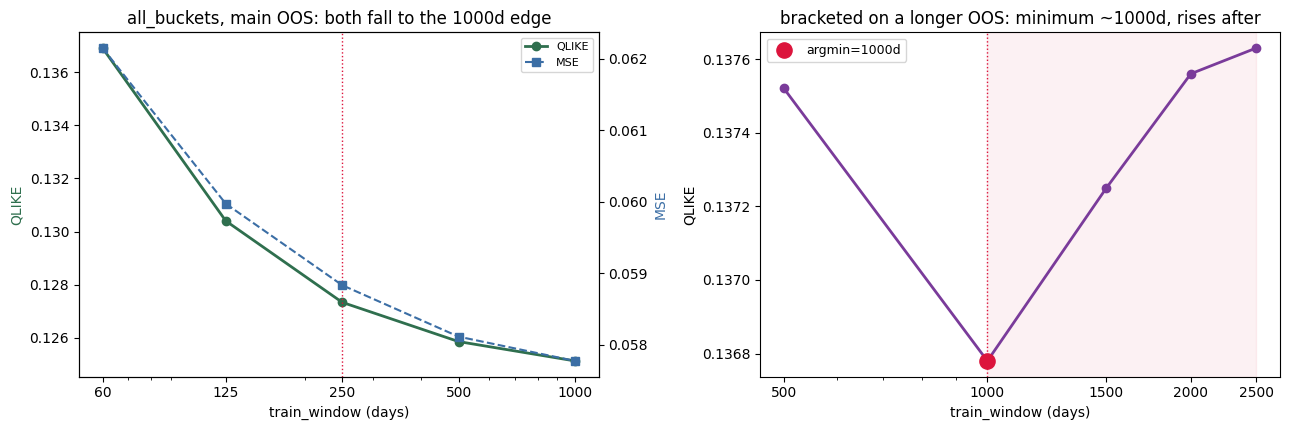

In [6]:
g = win[win.bucket=="all_buckets"].sort_values("window_days")
ext = win[win.bucket=="all_buckets_extOOS"].sort_values("window_days")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
l1,=axes[0].plot(g.window_days, g.qlike, "o-", color="#2f6f4e", lw=2, label="QLIKE")
axes[0].axvline(250, ls=":", c="crimson", lw=1); axes[0].set_xscale("log"); axes[0].set_xticks(g.window_days)
axes[0].get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax2=axes[0].twinx(); ax2.grid(False); l2,=ax2.plot(g.window_days, g.mse, "s--", color="#3b6ea5", label="MSE")
axes[0].set_xlabel("train_window (days)"); axes[0].set_ylabel("QLIKE", color="#2f6f4e"); ax2.set_ylabel("MSE", color="#3b6ea5")
axes[0].set_title("all_buckets, main OOS: both fall to the 1000d edge"); axes[0].legend(handles=[l1,l2], fontsize=8)
axes[1].plot(ext.window_days, ext.qlike, "o-", color="#7a3b9a", lw=2)
amin=ext.loc[ext.qlike.idxmin()]; axes[1].scatter([amin.window_days],[amin.qlike], s=120, color="crimson", zorder=5, label=f"argmin={int(amin.window_days)}d")
axes[1].axvline(1000, ls=":", c="crimson", lw=1); axes[1].axvspan(1000, ext.window_days.max(), color="crimson", alpha=0.06)
axes[1].set_xscale("log"); axes[1].set_xticks(ext.window_days)
axes[1].get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter()); axes[1].get_xaxis().set_minor_formatter(plt.matplotlib.ticker.NullFormatter())
axes[1].set_xlabel("train_window (days)"); axes[1].set_ylabel("QLIKE")
axes[1].set_title("bracketed on a longer OOS: minimum ~1000d, rises after"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

- **≈250 days is the optimum for every *single* bucket** (≈225 on a finer HAR grid, flat
  200–250); the 500-day default is suboptimal there (−0.0003 to −0.0014 QLIKE). For the
  single buckets QLIKE and MSE **diverge** (MSE wants ≥1000, QLIKE wants ~250).
- **The optimal window scales with model dimensionality, but saturates.** `all_buckets`
  (p≈529) breaks the 250 rule: QLIKE *and* MSE fall monotonically to 1000, and the
  extended sweep pins the minimum at **≈1000 days** — ~529 coefficients need more data, but
  past ~4 years it goes stale and QLIKE rises again. So "250 is universal" is the
  *parsimonious-model* optimum.
- **Production:** `train_window=250` for the HAR / single-bucket models (a deliberate
  re-baseline — every published number was at 500); a deployed `all_buckets` stack instead
  wants ≈1000.